# Apply the pipeline to your own data

**What this notebook teaches.**  How to take an arbitrary multivariate time series and run the full Kaur–Jain–Berman (2026) pipeline on it — wavelet → PCA → delay-embed → k-means → transition matrix $T(\tau)$ → G-PCCA — with the diagnostic criteria used in the manuscript.

**Who this is for.**  Anyone with a measured biological or physical signal that they suspect has a slow, hidden metastable structure underneath fast deterministic dynamics, and who wants a *non-stationary-aware* operator-based decomposition of that structure.

**What you'll need.**  A multivariate time series as a `(T, d)` numpy array, plus its sampling frequency in Hz.  Everything else (wavelet bands, embedding dimension, cluster count, working lag) is chosen automatically using the same data-driven criteria as the manuscript.

**Outline.**
1. Provide your data.
2. Run sanity checks on its shape, rate, and length.
3. Wavelet → PCA-with-shuffle-threshold → Cao $E_1(d)$ → delay embed → entropy-gap $N$ → k-means → implied-timescale plateau $\tau$ → $T(\tau)$ → eigendecomposition → G-PCCA.
4. Optionally compare the leading eigenvector to a known ground-truth driver (Lorenz Fig. 2D recipe) and run a per-individual analysis if your dataset has multiple recordings.

> Manuscript pointers: Methods Sec. "Transfer operator computations" + "Arm identification" for the canonical recipe.  Figures: `lorenz.ipynb`, `worms.ipynb`, `flies.ipynb` for worked examples on three different systems.

In [1]:

import os, sys, pickle, time
import numpy as np
import matplotlib.pyplot as plt

# Ensure slowmode/ is on the path.
sys.path.insert(0, os.path.abspath('.'))

import pipeline as pp
import gpcca_utils as gu
import figures as fg

fg.setup_style()
os.makedirs('outputs', exist_ok=True)


## 0. Provide your data

This example now loads one individual's keypoint-coordinate time series from
the local `moseq_dataverse` export instead of simulating the Lorenz system.
It groups recordings by the manifest `subject` field, loads all recordings
for the selected individual, and flattens all 25 tracked 3D keypoints into
`X.shape == (T_total, 75)`. Columns are ordered as keypoint 0 x/y/z,
keypoint 1 x/y/z, and so on.


## 0. Provide your data: size-normalized multi-species keypoints

This notebook now loads the local `moseq_dataverse/keypoint_moseq` export. It uses the parallel size-normalized datasets that were added to each session file:

- `size_normalized_coordinates`: `(T, 25, 3)` keypoints size-normalized to the reference mouse
- `size_normalized_distances`: `(T, 300)` unique all-to-all keypoint distances from those size-normalized coordinates

The cells below support two use cases:

1. Compare multiple species using per-individual streaming summaries, without loading all frames into memory.
2. Select one species/individual, or all individuals in one species with optional downsampling, to create `X`, `fs`, and `segment_lengths` for the slowmode pipeline below.


In [4]:
# === Size-normalized multi-species data pipeline ===
from pathlib import Path
import json
import h5py
import numpy as np
import pandas as pd

# Dataverse export produced in /Users/meganbishop/moseq_dataverse
# slowmodeevo lives next door, so keep this absolute path stable.
dataverse_root = Path('/Users/meganbishop/moseq_dataverse')
keypoint_root = dataverse_root / 'keypoint_moseq'
manifest_path = keypoint_root / 'manifest_by_species.csv'
metadata_path = keypoint_root / 'metadata.json'
source_dir = dataverse_root / 'data_files'

manifest = pd.read_csv(manifest_path)
manifest = manifest[manifest['status'].isin(['ok', 'exists'])].copy()
manifest['subject'] = manifest['subject'].astype(str)

with open(metadata_path) as f:
    keypoint_metadata = json.load(f)

available_species = sorted(manifest['species_folder'].dropna().unique())
print('Available species folders:')
print('\n'.join(f'  - {s}' for s in available_species))

DATASET_CHOICES = {
    'size_normalized_coordinates': 'size_normalized_coordinates',
    'size_normalized_distances': 'size_normalized_distances',
    # Kept for side-by-side checks if needed:
    'egocentric_coordinates': 'coordinates',
    'egocentric_distances': 'distances',
}


def _recording_path(row):
    return dataverse_root / row['output_file']


def _source_path(row):
    return source_dir / f"{row['recording_id']}.hdf5"


def _samplerate(row):
    with h5py.File(_source_path(row), 'r') as f:
        return float(f['recording'].attrs['samplerate'])


def _slice_for(max_frames=None, stride=1):
    stop = None if max_frames is None else int(max_frames) * int(stride)
    return slice(0, stop, int(stride))


def species_subjects(species_name):
    species_manifest = manifest[manifest['species_folder'] == species_name]
    if species_manifest.empty:
        available = ', '.join(available_species)
        raise ValueError(f'Unknown species {species_name!r}. Available: {available}')
    return sorted(species_manifest['subject'].dropna().astype(str).unique())


def select_manifest(species_name, individual_ids=None):
    species_manifest = manifest[manifest['species_folder'] == species_name].copy()
    if species_manifest.empty:
        available = ', '.join(available_species)
        raise ValueError(f'Unknown species {species_name!r}. Available: {available}')

    if individual_ids is None:
        keep = species_subjects(species_name)
    elif isinstance(individual_ids, (str, int, float)):
        keep = [str(individual_ids)]
    else:
        keep = [str(x) for x in individual_ids]

    missing = sorted(set(keep) - set(species_subjects(species_name)))
    if missing:
        preview = ', '.join(species_subjects(species_name)[:10])
        raise ValueError(f'{species_name}: unknown individual(s) {missing}. First available: {preview}')

    return species_manifest[species_manifest['subject'].astype(str).isin(keep)].sort_values(
        ['subject', 'recording_id']
    )


def load_individual_trace(
    species_name,
    individual_id=None,
    dataset_name='size_normalized_coordinates',
    stride=1,
    max_frames_per_recording=None,
    dtype=np.float32,
):
    """Load one individual's recordings and concatenate them into X.

    For coordinates, X is flattened keypoint-major: kp0_x, kp0_y, kp0_z, kp1_x, ...
    For distances, X has 300 columns using metadata['distance_pairs'] order.
    """
    dataset = DATASET_CHOICES[dataset_name]
    subjects = species_subjects(species_name)
    if individual_id is None:
        individual_id = subjects[0]
    individual_id = str(individual_id)

    rows = select_manifest(species_name, individual_id)
    if rows.empty:
        raise ValueError(f'No recordings found for {species_name} / {individual_id}')

    X_segments = []
    confidence_segments = []
    recording_ids = []
    samplerates = []
    segment_lengths = []
    slc = _slice_for(max_frames_per_recording, stride)

    for _, row in rows.iterrows():
        samplerates.append(_samplerate(row))
        with h5py.File(_recording_path(row), 'r') as f:
            values = f[dataset][slc]
            confidences = f['confidences'][slc]

        if values.ndim == 3:
            values = values.reshape(values.shape[0], values.shape[1] * values.shape[2])
        elif values.ndim != 2:
            raise ValueError(f'Expected 2D/3D dataset for {dataset}; got {values.shape}')

        X_segments.append(values.astype(dtype, copy=False))
        confidence_segments.append(confidences.astype(np.float32, copy=False))
        recording_ids.append(row['recording_id'])
        segment_lengths.append(values.shape[0])

    if len(set(samplerates)) != 1:
        raise ValueError(f'Multiple samplerates found for {species_name}/{individual_id}: {samplerates}')

    raw_fs = samplerates[0]
    fs = raw_fs / int(stride)
    X = np.concatenate(X_segments, axis=0)
    confidences = np.concatenate(confidence_segments, axis=0)

    return {
        'species_folder': species_name,
        'individual_id': individual_id,
        'dataset_name': dataset_name,
        'dataset': dataset,
        'X': X,
        'confidences': confidences,
        'recording_ids': recording_ids,
        'segment_lengths': np.array(segment_lengths, dtype=int),
        'raw_fs': raw_fs,
        'fs': fs,
        'stride': int(stride),
        'n_recordings': len(recording_ids),
    }


def load_species_traces(
    species_names,
    dataset_name='size_normalized_coordinates',
    individual_ids_by_species=None,
    stride=1,
    max_frames_per_recording=None,
    max_individuals_per_species=None,
):
    """Load all requested individuals, grouped by species.

    Be careful with stride=1 across many animals: this can be hundreds of GB in RAM.
    Use stride or max_frames_per_recording for exploratory cross-species comparisons.
    """
    if isinstance(species_names, str):
        species_names = [species_names]
    individual_ids_by_species = individual_ids_by_species or {}

    out = {}
    for species_name in species_names:
        ids = individual_ids_by_species.get(species_name)
        if ids is None:
            ids = species_subjects(species_name)
        if max_individuals_per_species is not None:
            ids = ids[:max_individuals_per_species]

        out[species_name] = {}
        for individual_id in ids:
            out[species_name][str(individual_id)] = load_individual_trace(
                species_name,
                individual_id=individual_id,
                dataset_name=dataset_name,
                stride=stride,
                max_frames_per_recording=max_frames_per_recording,
            )
    return out


def summarize_individual(
    species_name,
    individual_id,
    dataset_name='size_normalized_coordinates',
    stride=120,
    max_frames_per_recording=None,
):
    """Streaming per-individual feature summary for cross-species comparisons."""
    dataset = DATASET_CHOICES[dataset_name]
    rows = select_manifest(species_name, individual_id)
    slc = _slice_for(max_frames_per_recording, stride)

    n = 0
    sum_x = None
    sum_x2 = None
    mean_conf_num = 0.0
    recording_ids = []
    samplerates = []

    for _, row in rows.iterrows():
        samplerates.append(_samplerate(row))
        with h5py.File(_recording_path(row), 'r') as f:
            values = f[dataset][slc]
            conf = f['confidences'][slc]
        if values.ndim == 3:
            values = values.reshape(values.shape[0], values.shape[1] * values.shape[2])
        values = values.astype(np.float64, copy=False)

        if sum_x is None:
            sum_x = np.zeros(values.shape[1], dtype=np.float64)
            sum_x2 = np.zeros(values.shape[1], dtype=np.float64)
        sum_x += values.sum(axis=0)
        sum_x2 += np.square(values).sum(axis=0)
        mean_conf_num += float(np.asarray(conf, dtype=np.float64).sum())
        n += values.shape[0]
        recording_ids.append(row['recording_id'])

    if n == 0:
        raise ValueError(f'No frames loaded for {species_name}/{individual_id}')
    if len(set(samplerates)) != 1:
        raise ValueError(f'Multiple samplerates found for {species_name}/{individual_id}: {samplerates}')

    mean = sum_x / n
    var = np.maximum(sum_x2 / n - mean * mean, 0.0)
    std = np.sqrt(var)
    n_keypoints = 25
    mean_confidence = mean_conf_num / (n * n_keypoints)

    return {
        'species_folder': species_name,
        'individual_id': str(individual_id),
        'dataset_name': dataset_name,
        'n_recordings': len(recording_ids),
        'n_frames_used': int(n),
        'raw_fs': samplerates[0],
        'effective_fs': samplerates[0] / int(stride),
        'stride': int(stride),
        'mean_confidence': mean_confidence,
        'feature_mean': mean,
        'feature_std': std,
        'recording_ids': recording_ids,
    }


def compare_species(
    species_names,
    dataset_name='size_normalized_coordinates',
    stride=120,
    max_frames_per_recording=None,
    max_individuals_per_species=None,
):
    """Return one row per individual plus mean/std feature vectors for comparisons."""
    if isinstance(species_names, str):
        species_names = [species_names]

    rows = []
    feature_means = {}
    feature_stds = {}
    for species_name in species_names:
        ids = species_subjects(species_name)
        if max_individuals_per_species is not None:
            ids = ids[:max_individuals_per_species]
        for individual_id in ids:
            summary = summarize_individual(
                species_name,
                individual_id,
                dataset_name=dataset_name,
                stride=stride,
                max_frames_per_recording=max_frames_per_recording,
            )
            key = (species_name, str(individual_id))
            feature_means[key] = summary.pop('feature_mean')
            feature_stds[key] = summary.pop('feature_std')
            summary['key'] = key
            rows.append(summary)

    summary_df = pd.DataFrame(rows)
    return summary_df, feature_means, feature_stds


Available species folders:
  - Mus_caroli
  - Mus_musculus
  - Mus_spretus
  - Peromyscus_californicus
  - Peromyscus_gossypinus
  - Peromyscus_leucopus
  - Peromyscus_maniculatus
  - Peromyscus_polionotus


In [5]:
X.shape()

NameError: name 'X' is not defined

In [20]:
pipeline_dataset = 'size_normalized_coordinates'
pipeline_stride = 1
pipeline_max_frames_per_recording = None

# Random subset for pooled runs. Set to None to use all individuals in the species.
pipeline_random_n_individuals = None    # e.g. 5; None -> all individuals
pipeline_random_seed = 14

#  PCA is fit from every Nth wavelet row per individual.Every loaded frame is still wavelet-transformed and projected afterward.
wavelet_subsample_factor = 50        
kmeans_subsample_factor = 20         

# Pipeline parameters; tune below with the diagnostic cells.
d_embed = 7
N = 200
tau_seconds = 10.0
M = 4

In [10]:

# memory safe run: wavelets computed seperately, sampled for shared PCA 

pipeline_by_individual = True       

# for concatenated runs: best for only a couple species

pipeline_species = 'Mus_spretus'
pipeline_individual_id = None       # None -> first individual in species
pipeline_all_individuals = True     
pipeline_dataset = 'size_normalized_coordinates'
pipeline_stride = 1
pipeline_max_frames_per_recording = None

# Random subset for pooled runs. Set to None to use all individuals in the species.
pipeline_random_n_individuals = None    # e.g. 5; None -> all individuals
pipeline_random_seed = 14

#  PCA is fit from every Nth wavelet row per individual.Every loaded frame is still wavelet-transformed and projected afterward.
wavelet_subsample_factor = 50        
kmeans_subsample_factor = 20         

# Pipeline parameters; tune below with the diagnostic cells.
d_embed = 10
N = 200
tau_seconds = 5.0
M = 4

if pipeline_all_individuals:
    all_ids = species_subjects(pipeline_species)
    if pipeline_random_n_individuals is None:
        pipeline_selected_individual_ids = all_ids
    else:
        rng = np.random.default_rng(pipeline_random_seed)
        n_sample = min(int(pipeline_random_n_individuals), len(all_ids))
        pipeline_selected_individual_ids = rng.choice(all_ids, size=n_sample, replace=False).tolist()
        print(f'Randomly sampled {n_sample}/{len(all_ids)} individuals with seed {pipeline_random_seed}:')
        print(pipeline_selected_individual_ids)
else:
    subjects = species_subjects(pipeline_species)
    pipeline_selected_individual_ids = [str(pipeline_individual_id or subjects[0])]

# Read the sampling rate without loading all frames.
first_row = select_manifest(pipeline_species, pipeline_selected_individual_ids[0]).iloc[0]
raw_fs = _samplerate(first_row)
fs = raw_fs / int(pipeline_stride)
fmin, fmax = 0.1, min(60.0, 0.45 * fs)
n_freqs = 25


if pipeline_by_individual:
    X = None
    confidences = None
    recording_ids = []
    segment_lengths = np.array([], dtype=int)
    individual_id = 'POOLED_BY_INDIVIDUAL'
    individual_label = individual_id
    print(f'pipeline_species = {pipeline_species}')
    print(f'individuals selected = {len(pipeline_selected_individual_ids)}')
    print(f'first individual_ids = {pipeline_selected_individual_ids[:5]}')
    print(f'dataset = {pipeline_dataset}')
    print(f'sampling at {fs} Hz; f range = [{fmin:.2f}, {fmax:.2f}] Hz')
    print(f'wavelet_subsample_factor = {wavelet_subsample_factor}')
    print('Memory-safe mode: run the pooled-by-individual cell below, then skip sections 1-9.')
else:
    if pipeline_all_individuals:
        species_traces = load_species_traces(
            [pipeline_species],
            dataset_name=pipeline_dataset,
            individual_ids_by_species={pipeline_species: pipeline_selected_individual_ids},
            stride=pipeline_stride,
            max_frames_per_recording=pipeline_max_frames_per_recording,
        )[pipeline_species]

        X_segments = [bundle['X'] for bundle in species_traces.values()]
        X = np.concatenate(X_segments, axis=0)
        fs_values = {bundle['fs'] for bundle in species_traces.values()}
        if len(fs_values) != 1:
            raise ValueError(f'Multiple effective samplerates: {fs_values}')
        fs = fs_values.pop()
        segment_lengths = np.concatenate([bundle['segment_lengths'] for bundle in species_traces.values()])
        recording_ids = [rid for bundle in species_traces.values() for rid in bundle['recording_ids']]
        individual_id = 'SELECTED_INDIVIDUALS'
        individual_label = individual_id
        confidences = np.concatenate([bundle['confidences'] for bundle in species_traces.values()], axis=0)
    else:
        bundle = load_individual_trace(
            pipeline_species,
            individual_id=pipeline_selected_individual_ids[0],
            dataset_name=pipeline_dataset,
            stride=pipeline_stride,
            max_frames_per_recording=pipeline_max_frames_per_recording,
        )
        X = bundle['X']
        fs = bundle['fs']
        segment_lengths = bundle['segment_lengths']
        recording_ids = bundle['recording_ids']
        individual_id = bundle['individual_id']
        individual_label = individual_id.rstrip('0').rstrip('.')
        confidences = bundle['confidences']

    n_features = X.shape[1]
    print(f'pipeline_species = {pipeline_species}')
    print(f'individual_id = {individual_label}')
    print(f'dataset = {pipeline_dataset}')
    print(f'n_recordings = {len(recording_ids)}; first recording_ids = {recording_ids[:5]}')
    print(f'segment lengths = {segment_lengths.tolist()[:10]}')
    print(f'X shape = {X.shape}; sampling at {fs} Hz')
    print(f'n_features = {n_features}')
    print(f'mean keypoint confidence = {confidences.mean():.3f}')


pipeline_species = Mus_spretus
individuals selected = 16
first individual_ids = ['SPRET-F-L-730', 'SPRET-F-L-732', 'SPRET-F-L-742', 'SPRET-F-LR-730', 'SPRET-F-N-731']
dataset = size_normalized_coordinates
sampling at 120.0 Hz; f range = [0.10, 54.00] Hz
wavelet_subsample_factor = 50
Memory-safe mode: run the pooled-by-individual cell below, then skip sections 1-9.


In [11]:
np.shape(X)

()

In [18]:
import numpy as np

def sanity_check(X, fs, fmin, fmax, N_planned=None, slowest_dwell_s=None):
    """Print warnings / OK messages for the standard pipeline assumptions."""
    X = np.asarray(X)
    if X.ndim == 1:
        X = X[:, None]
    T, d = X.shape

    print(f'Input shape:        (T={T}, d={d}); sampling rate fs={fs} Hz')
    print(f'Recording length:   {T / fs:.1f} s ({T / fs / 60:.1f} min)')

    if not np.isfinite(X).all():
        n_bad = int((~np.isfinite(X)).sum())
        print(f'  WARN: {n_bad} non-finite entries; mask or interpolate before running wavelet.')
    else:
        print('  OK: no NaNs / infs.')

    if fmax > fs / 2:
        print(f'  WARN: fmax={fmax} Hz exceeds Nyquist fs/2={fs/2} Hz.  Lower fmax.')
    if fmin <= 0:
        print(f'  WARN: fmin={fmin} Hz must be > 0.')
    period_at_fmin = 1.0 / fmin
    if T / fs < 10 * period_at_fmin:
        print(f'  WARN: recording shorter than 10 cycles of fmin (~{10 * period_at_fmin:.0f} s).  '
              f'PCA of the wavelet amplitudes may be unreliable.')

    if N_planned is not None:
        ratio = T / N_planned
        if ratio < 500:
            print(f'  WARN: T/N = {ratio:.0f} < 500 -- consider reducing N or recording longer.')
        else:
            print(f'  OK: T/N = {ratio:.0f} (>= 500 frames per cluster).')

    if slowest_dwell_s is not None:
        ratio = (T / fs) / slowest_dwell_s
        if ratio < 10:
            print(f'  WARN: recording is only {ratio:.1f}x the slowest expected dwell '
                  f'({slowest_dwell_s:.1f} s).  Aim for >= 10x.')
        else:
            print(f'  OK: recording is {ratio:.0f}x the slowest expected dwell.')

# Run the checks now -- edit the slowest_dwell_s estimate to match your system.
if pipeline_by_individual:
    total_frames = 0
    for _individual_id in pipeline_selected_individual_ids:
        for _, _row in select_manifest(pipeline_species, _individual_id).iterrows():
            with h5py.File(_recording_path(_row), 'r') as _f:
                total_frames += _f[DATASET_CHOICES[pipeline_dataset]][_slice_for(pipeline_max_frames_per_recording, pipeline_stride)].shape[0]
    print(f'Input shape:        pooled T={total_frames}, sampled individuals={len(pipeline_selected_individual_ids)}; sampling rate fs={fs} Hz')
    print(f'Recording length:   {total_frames / fs:.1f} s ({total_frames / fs / 60:.1f} min)')
    print('  OK: pooled-by-individual mode avoids concatenating all wavelet amplitudes in RAM.')
else:
    sanity_check(X, fs=fs, fmin=fmin, fmax=fmax,
                 N_planned=200,            # set to your planned k-means N
                 slowest_dwell_s=10.0)     # rough estimate; can be order-of-magnitude

Input shape:        pooled T=9720360, sampled individuals=16; sampling rate fs=120.0 Hz
Recording length:   81003.0 s (1350.0 min)
  OK: pooled-by-individual mode avoids concatenating all wavelet amplitudes in RAM.


## Memory-safe pooled-by-individual preparation

This cell computes the expensive shared representation only: wavelets are computed for each individual, every `wavelet_subsample_factor` row is pooled to fit one shared PCA basis, then each individual's wavelets are recomputed and every frame is projected onto that basis. After this cell, continue through the tuning sections below to choose `d_embed`, `N`, `tau_seconds`, and `M`.


In [6]:
if pipeline_by_individual:
    import importlib
    import pooled_user_pipeline
    importlib.reload(pooled_user_pipeline)
    from pooled_user_pipeline import prepare_pooled_individual_projections

    projection_result = prepare_pooled_individual_projections(
        pipeline_species=pipeline_species,
        individual_ids=pipeline_selected_individual_ids,
        load_individual_trace_fn=load_individual_trace,
        dataset_name=pipeline_dataset,
        stride=pipeline_stride,
        max_frames_per_recording=pipeline_max_frames_per_recording,
        fs=fs,
        fmin=fmin,
        fmax=fmax,
        n_freqs=n_freqs,
        output_dir=f'outputs/pooled_by_individual/{pipeline_species}',
        wavelet_subsample_factor=wavelet_subsample_factor,
        pca_max_components=30,
        n_shuffles=10,
        seed=pipeline_random_seed,
        verbose=True,
    )

    freqs = projection_result['frequencies']
    n_kept = projection_result['n_kept']
    eigvals_pca = projection_result['eigvals_pca']
    thresh = projection_result['shuffle_threshold']
    proj_files = projection_result['proj_files']
    pooled_output_dir = projection_result['output_dir']

    print(f'saved projected individuals = {len(proj_files)}')
    print(f'kept {n_kept} shared PCs above threshold {thresh:.3g}')
else:
    print('pipeline_by_individual is False; use the standard single-X cells below.')


Pass 1/3: compute each individual's wavelets, keep every 50 row for shared PCA
  [1/16] SPRET-F-L-730: X=(648024, 75)


KeyboardInterrupt: 

## 1. Wavelet decomposition

Morlet wavelet amplitudes with $\omega_0 = 5$ across `n_freqs` dyadically
spaced bands in $[f_\mathrm{min}, f_\mathrm{max}]$.  Output is
`(T, d * n_freqs)` (channel-major).


In [9]:
if pipeline_by_individual:
    print('Pooled mode: wavelets and shared PCA projections were computed in the preparation cell.')
    print(f'freq range = [{freqs[0]:.2f}, {freqs[-1]:.2f}] Hz')
else:
    amps, freqs = pp.morlet_wavelet_amplitudes(X, fs=fs, fmin=fmin, fmax=fmax,
                                                n_freqs=n_freqs)
    print(f'wavelet amplitudes shape = {amps.shape}')
    print(f'freq range = [{freqs[0]:.2f}, {freqs[-1]:.2f}] Hz')


Pooled mode: wavelets and shared PCA projections were computed in the preparation cell.


NameError: name 'freqs' is not defined

## 2. PCA with phase-shuffle threshold

We keep the components whose eigenvalues exceed the mean of $\lambda_1$
across phase-shuffled copies of the wavelet matrix.  Increase `n_shuffles`
for tighter estimates.


In [10]:
if pipeline_by_individual:
    print(f'kept {n_kept} shared PCs above threshold {thresh:.3g}')
    fig, ax = plt.subplots(figsize=(4.0, 2.8))
    ax.plot(np.arange(1, len(eigvals_pca) + 1), eigvals_pca, 'o-')
    ax.axhline(thresh, ls='--', color='r', label='shuffle threshold')
    ax.set_yscale('log')
    ax.set_xlabel('PC index'); ax.set_ylabel('eigenvalue'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    proj, n_kept, eigvals_pca, thresh = pp.pca_with_shuffle_threshold(
        amps, n_shuffles=10, max_keep=20, seed=0)
    print(f'kept {n_kept} components above threshold {thresh:.3g}')

    fig, ax = plt.subplots(figsize=(4.0, 2.8))
    ax.plot(np.arange(1, len(eigvals_pca) + 1), eigvals_pca, 'o-')
    ax.axhline(thresh, ls='--', color='r', label='shuffle threshold')
    ax.set_yscale('log')
    ax.set_xlabel('PC index'); ax.set_ylabel('eigenvalue'); ax.legend()
    plt.tight_layout(); plt.show()


NameError: name 'n_kept' is not defined

## 3. Cao's $E_1(d)$ to choose the embedding dimension

We pick the smallest $d$ at which $E_1(d)$ saturates near 1.  In the
manuscript this is $d = 7$ for Lorenz/worms and $d = 12$ for flies.


In [51]:
if pipeline_by_individual:
    from pooled_user_pipeline import projection_sample_for_tuning
    proj_tune = projection_sample_for_tuning(proj_files, subsample_factor=kmeans_subsample_factor)
    E1 = pp.cao_e1(proj_tune[:, :n_kept], max_d=15, tau=5, n_samples=20000, seed=0)
else:
    E1 = pp.cao_e1(proj[:, :n_kept], max_d=15, tau=5, n_samples=20000, seed=0)

fig, ax = plt.subplots(figsize=(4.0, 2.8))
ax.plot(np.arange(2, len(E1) + 2), E1, 'o-')
ax.axhline(1.0, ls=':', color='0.6')
ax.set_xlabel('$d$'); ax.set_ylabel('$E_1(d)$')
plt.tight_layout(); plt.show()

# Set d_embed to the chosen saturation point (e.g. by eye on the plot).
print(f'current choice: d_embed = {d_embed}')


Skipping Cao E1 cell; inspect pooled PCA settings or run a smaller single-X subset for this diagnostic.


## 4. Delay embedding


In [52]:
if pipeline_by_individual:
    print('Pooled mode: delay embedding is applied from saved projections when fitting k-means below.')
    print(f'current choice: d_embed = {d_embed}')
else:
    X_embedded = pp.delay_embed(proj[:, :n_kept], d=d_embed, tau=1)
    print(f'delay-embedded shape = {X_embedded.shape}')


Skipping standard delay-embedding cell; pooled states were assigned per individual.


## 5. Choose $N$ via the entropy gap $\Delta H(N)$

$\Delta H(N) = H_\mathrm{shuf}(N) - H(N)$ is largest at the optimal $N$
(Methods, Sec. "Choosing the number of clusters").


In [53]:
N_values = [50, 100, 200, 400, 800]
lag_demo = int(tau_seconds * fs)

if pipeline_by_individual:
    from pooled_user_pipeline import entropy_gap_pooled_projections
    Ns, H, Hs = entropy_gap_pooled_projections(
        proj_files=proj_files,
        d_embed=d_embed,
        N_values=N_values,
        lag=lag_demo,
        framerate=fs,
        kmeans_subsample_factor=kmeans_subsample_factor,
        seed=pipeline_random_seed,
        n_init=5,
        verbose=True,
    )
else:
    Ns, H, Hs = pp.entropy_gap(X_embedded, N_values, lag=lag_demo,
                                framerate=fs, seed=0, n_init=5, verbose=True)

fig, ax = plt.subplots(figsize=(4.0, 2.8))
ax.plot(Ns, Hs - H, 'o-')
ax.set_xscale('log'); ax.set_xlabel('$N$')
ax.set_ylabel(r'$\Delta H(N)$ (nats/s)')
plt.tight_layout(); plt.show()

# Adjust N to the maximum of Delta H(N) above (or stick with the demo N).
print(f'current choice: N = {N}')


Skipping entropy-gap sweep; pooled k-means already used N. Run a smaller subset to tune N if needed.


## 6. K-means partition


In [54]:
if pipeline_by_individual:
    from pooled_user_pipeline import assign_pooled_states_from_projections
    state_result = assign_pooled_states_from_projections(
        proj_files=proj_files,
        d_embed=d_embed,
        N=N,
        output_dir=pooled_output_dir,
        kmeans_subsample_factor=kmeans_subsample_factor,
        seed=pipeline_random_seed,
        kmeans_n_init=20,
        verbose=True,
    )
    states_list = state_result['states_list']
    state_files = state_result['state_files']
    kmeans = state_result['kmeans']
    states = np.concatenate(states_list)  # compatibility for plotting cells
    print(f'partitioned into N = {N} clusters; pooled sequence length = {len(states):,}')
else:
    states = pp.kmeans_partition(X_embedded, N=N, n_init=20, seed=0)
    print(f'partitioned into N = {N} clusters; sequence length = {len(states):,}')


Skipping standard k-means cell; pooled shared k-means already assigned states_list.


## 7. Choose $\tau$ via the implied-timescales plateau

Sweep $\tau$ and look for a range over which the leading implied
timescales $t_k = -\tau / \log|\lambda_k(\tau)|$ are roughly constant
in $\tau$.  Pick the working lag inside that plateau.


In [55]:
lags_s = np.array([0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0])
implied = []
for ls_ in lags_s:
    lg = max(int(ls_ * fs), 1)
    Tt = pp.make_transition_matrix(states_list if pipeline_by_individual else states, lag=lg, n_states=N)
    e, _ = pp.leading_eigvecs(Tt, k=4)
    implied.append(-(lg / fs) / np.log(np.maximum(np.abs(e[:4]), 1e-12)))
implied = np.array(implied)
fig, ax = plt.subplots(figsize=(4.4, 3.0))
for k in range(3):
    ax.plot(lags_s, implied[:, k], 'o-', label=fr'$t_{{{k+2}}}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\tau$ (s)'); ax.set_ylabel('implied timescale (s)')
ax.legend()
plt.tight_layout(); plt.show()

print(f'current choice: tau = {tau_seconds} s')


Skipping standard tau sweep; use pooled states_list if you want to sweep tau.


## 8. Transition matrix and eigendecomposition


In [56]:
lag = int(tau_seconds * fs)
T = pp.make_transition_matrix(states_list if pipeline_by_individual else states, lag=lag, n_states=N)
pi = pp.stationary_distribution(T)
evals, evecs = pp.leading_eigvecs(T, k=10)
print(f'leading |lambda_k| = {np.abs(evals)[:6].round(4)}')

# Spectral gap selection of M.
M_pick, gap, ratios = gu.select_M_spectral_gap(evals, M_min=2, M_max=8)
print(f'spectral gap selects M = {M_pick} (ratio = {gap:.3f})')


Skipping standard transition/eigendecomposition cell; pooled T/evals are already set.


## 9. G-PCCA at the chosen $M$


In [57]:
out = gu.run_gpcca(T, M=M, eta=pi)
chi = out['chi']
print(f'crispness    = {out["crispness"]:.3f}')
print(f'basin counts = {out["basin_counts"]}')
print(f'pi per basin = {out["pi_basin"].round(3)}')


Skipping standard G-PCCA cell; pooled chi is already set.


## Save pooled outputs

Save per-individual cluster allocation files, a compact allocation manifest, the transfer operator, the selected parameter values, and the arms/eigenspace plot for the current species.


In [ ]:
save_outputs = True

if save_outputs:
    from pooled_user_pipeline import save_pooled_outputs

    run_parameters = {
        'species': pipeline_species,
        'dataset': pipeline_dataset,
        'n_individuals': len(pipeline_selected_individual_ids),
        'individual_selection_seed': pipeline_random_seed,
        'pipeline_stride': pipeline_stride,
        'max_frames_per_recording': pipeline_max_frames_per_recording,
        'fs': fs,
        'fmin': fmin,
        'fmax': fmax,
        'n_freqs': n_freqs,
        'wavelet_subsample_factor': wavelet_subsample_factor,
        'kmeans_subsample_factor': kmeans_subsample_factor,
        'n_kept_pcs': n_kept,
        'pca_shuffle_threshold': thresh,
        'd_embed': d_embed,
        'N': N,
        'tau_seconds': tau_seconds,
        'lag_frames': lag,
        'M': M,
        'gpcca_crispness': out['crispness'],
        'basin_counts': out['basin_counts'].tolist(),
        'pi_basin': out['pi_basin'].round(6).tolist(),
    }

    saved_outputs = save_pooled_outputs(
        output_dir=f'outputs/pooled_by_individual/{pipeline_species}/final_outputs',
        species=pipeline_species,
        individual_ids=pipeline_selected_individual_ids,
        state_files=state_files if pipeline_by_individual else [],
        states_list=states_list if pipeline_by_individual else [states],
        T=T,
        pi=pi,
        evals=evals,
        evecs=evecs,
        chi=chi,
        parameters=run_parameters,
        metadata=projection_result.get('metadata') if pipeline_by_individual else None,
    )
    saved_outputs


## Batch run across species

Use this optional cell after choosing `d_embed`, `N`, `tau_seconds`, and `M`. It runs the pooled-by-individual pipeline for each species in `batch_species`, saves that species immediately under `outputs/pooled_by_individual/<species>/final_outputs`, and updates `outputs/pooled_by_individual/batch_summary.csv` after every completed species.


In [ ]:
run_batch_across_species = True
batch_species = available_species  # or set explicitly, e.g. ['Mus_spretus', 'Peromyscus_maniculatus']

if run_batch_across_species:
    import importlib
    import pooled_user_pipeline
    importlib.reload(pooled_user_pipeline)
    from pooled_user_pipeline import run_species_batch

    batch_summary_df = run_species_batch(
        species_names=batch_species,
        species_subjects_fn=species_subjects,
        select_manifest_fn=select_manifest,
        samplerate_fn=_samplerate,
        load_individual_trace_fn=load_individual_trace,
        dataset_name=pipeline_dataset,
        stride=pipeline_stride,
        max_frames_per_recording=pipeline_max_frames_per_recording,
        n_freqs=n_freqs,
        d_embed=d_embed,
        N=N,
        tau_seconds=tau_seconds,
        M=M,
        output_root='outputs/pooled_by_individual',
        random_n_individuals=pipeline_random_n_individuals,
        seed=pipeline_random_seed,
        wavelet_subsample_factor=wavelet_subsample_factor,
        kmeans_subsample_factor=kmeans_subsample_factor,
        pca_max_components=20,
        n_shuffles=10,
        kmeans_n_init=20,
        fmin=0.1,
        fmax_cap=60.0,
        verbose=True,
    )
    batch_summary_df
else:
    print('Set run_batch_across_species = True after tuning parameters to launch the species loop.')



=== Mus_caroli: 15 individuals ===
fs=120 Hz, f range=[0.1, 54] Hz
Pass 1/3: compute each individual's wavelets, keep every 50 row for shared PCA
  [1/15] CAROLI-F-2L-741: X=(432016, 75)
  [2/15] CAROLI-F-L-737: X=(648024, 75)


## 10. Eigenvalue spectrum


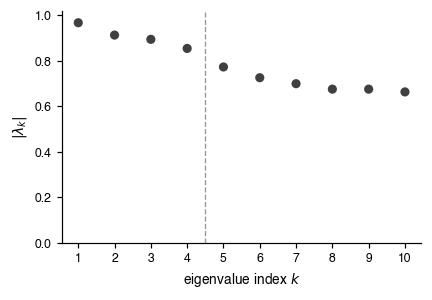

In [58]:
fig, ax = plt.subplots(figsize=(4.0, 2.8))
fg.plot_eigenvalue_dots(ax, evals[:10], M=M)
plt.tight_layout(); plt.show()


## 11. 3D eigenspace with hub and arms


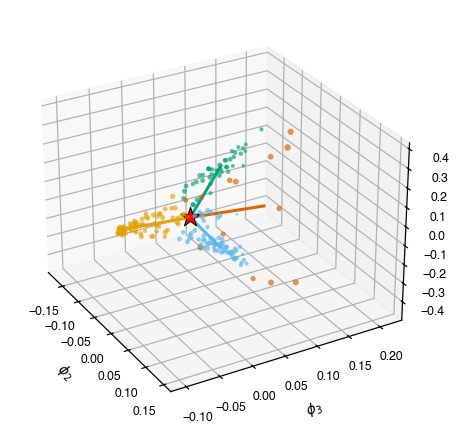

In [73]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
phi = evecs[:, 1:4].real
geo = gu.compute_hub_arms(phi, pi, chi)

fig = plt.figure(figsize=(4.6, 4.0))
ax = fig.add_subplot(111, projection='3d')
fg.plot_eigenspace_3d(ax, phi, pi=pi, chi=chi,
                       hub=geo['hub'], arm_dirs=geo['arm_dirs'],
                       arm_centroids=geo['arm_centroids'])
plt.tight_layout(); plt.show()


## 12. $\chi_j(t)$ time series

Soft basin memberships over time, smoothed with a 5 s rolling window.


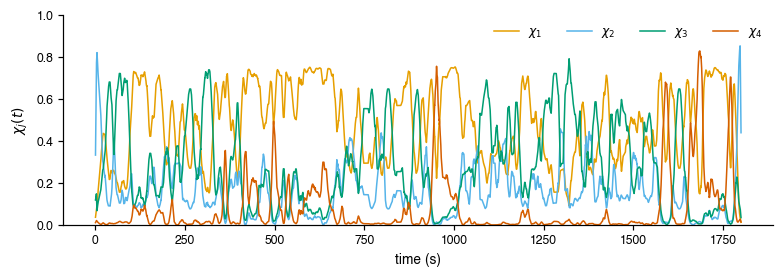

In [60]:
chi_traces = chi[states]
T_show = min(len(chi_traces), 30 * 60 * int(fs))   # up to 30 minutes
t_show = np.arange(T_show) / fs

fig, ax = plt.subplots(figsize=(7.2, 2.6))
fg.plot_chi_timeseries(ax, t_show, chi_traces[:T_show],
                        smoothing_window=int(5 * fs))
plt.tight_layout(); plt.show()


## 13. Optional: $r_k(\tau)$ non-Markovianity signature

If your dynamics are Markovian at the chosen state resolution,
$r_k(\tau) = -\log|\lambda_k(\tau)|/\tau$ is constant in $\tau$.  The
strong decrease of $r_2$ with $\tau$ is the operator-level non-Markovianity
documented in Berman et al. (2016) and reproduced in Fig. 5B of the
manuscript.


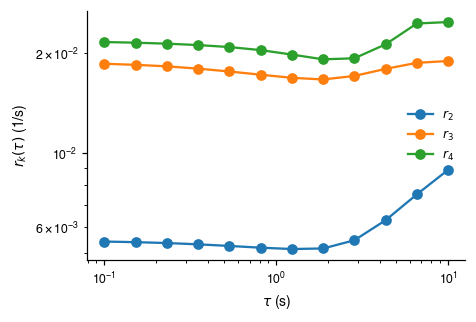

In [61]:
lags_s = np.logspace(-1, 1, 12)
rk = []
for ls_ in lags_s:
    lg = max(int(ls_ * fs), 1)
    Tt = pp.make_transition_matrix(states_list if pipeline_by_individual else states, lag=lg, n_states=N)
    e, _ = pp.leading_eigvecs(Tt, k=4)
    rk.append(-np.log(np.maximum(np.abs(e[:4]), 1e-12)) / (lg / fs))
rk = np.array(rk)
fig, ax = plt.subplots(figsize=(4.4, 3.0))
for k in range(3):
    ax.plot(lags_s, rk[:, k], 'o-', label=fr'$r_{{{k+2}}}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\tau$ (s)'); ax.set_ylabel(r'$r_k(\tau)$ (1/s)')
ax.legend()
plt.tight_layout(); plt.show()


## 14. Pooling multiple individuals + the four diagnostics

If you have several recordings, keep them as a **list** of per-individual
cluster sequences and pass the list directly — `make_transition_matrix`
counts transitions *within* each sequence only, never across the splice
between individuals. `diagnostics.run_diagnostics` then evaluates the paper's
four falsifiable criteria (spectral gap, participation ratio, simplex/arms
geometry, and held-out prediction beating a memoryless null) in one call, and
`diagnostics.stationarity_drift` flags violations of the single-stationary-
distribution assumption.

(Criterion (iv) needs >= 2 individuals; with the single demo sequence here it
returns "n/a".)

In [62]:
import diagnostics as dx

# In pooled-by-individual mode, states_list already contains one sequence per individual.
if not pipeline_by_individual:
    states_list = [states]

T_pool = pp.make_transition_matrix(states_list, lag=lag, n_states=N)
pi_pool = pp.stationary_distribution(T_pool)
evals_pool, evecs_pool = pp.leading_eigvecs(T_pool, k=10)
out_pool = gu.run_gpcca(T_pool, M=M, eta=pi_pool)

report = dx.run_diagnostics(states_list, out_pool['chi'], evals_pool,
                            evecs_pool[:, :max(M - 1, 1)].real, pi_pool,
                            lag=lag, M=M)
print('\nbasin-occupancy drift (max TV across windows):',
      round(dx.stationarity_drift(states_list, out_pool['chi'])['max_tv'], 3))

criterion                  value   result
----------------------------------------------
(i)  spectral gap          1.047   FAIL
(ii) participation        72.209   PASS
(iii) simplex geom.        0.912   PASS
(iv) held-out > null       1.187   PASS

basin-occupancy drift (max TV across windows): 0.398


---

## Recap

You've now run the full multi-timescale transfer-operator pipeline on your
own data, with the same diagnostic criteria the paper uses.  All cached
quantities (`X_embedded`, `states`, `T`, `pi`, `chi`, `geo`) are available
in your kernel for downstream analyses (basin-level Markov modeling,
$r_k(\tau)$ over a wider grid, dwell-time fits, behavior-map enrichment
maps, leave-one-individual-out CV, etc.).  See `flies.ipynb` for a worked
example of the full set.


## 14. Optional: ground-truth correlation (Lorenz Fig. 2D recipe)

If you have an external "hidden driver" $h(t)$ aligned to your time series
(synthetic data, or a known modulator), `pipeline.phi2_correlation_preet`
computes $|r(\phi_2(t), h(t))|$ using the per-seed characteristic-timescale
lag and Savitzky-Golay smoothing convention used in the manuscript Fig. 2D
$\beta$ sweep.

```python
r, lag, t_c = pp.phi2_correlation_preet(states, h, fs=fs)
print(f'|r| = {r:.3f}    lag = {lag}    t_c = {t_c:.1f} frames')
```

The recipe is: $T(\mathrm{lag}=1)$ → $t_c = -1/\log|\lambda_2|$ →
$T(\mathrm{round}(t_c))$ → leading non-trivial right eigenvector by
descending real-eigenvalue → savgol-smooth → Pearson.


## 15. Optional: metastable dwell-time tails

A recurring empirical signature in the paper is that the metastable
*residence times* are broad and heavy-tailed, best described by a truncated
power law $f(\tau)\propto\tau^{-\alpha}e^{-\lambda\tau}$ (main Fig. 5D; Supp.
Fig. S8).  Two robustness checks accompany this (Methods Sec. "Dwell-time
distributions"):

1. **One-step-Markov surrogate null (Supp. Fig. S10).** Replace the cluster
   sequence with a first-order Markov chain fit to its lag-1 transitions, pass
   it through the *identical* $\Delta$-smoothing + arg max residence pipeline,
   and confirm the data tail is heavier than the memoryless surrogate.
2. **Smoothing-scale robustness (Supp. Fig. S11).** Refit across the membership
   smoothing scale $\Delta$ and confirm the exponential cutoff $1/\lambda$ is
   set by the dynamics, not by $\Delta$.

`pipeline.metastable_residences(states_list, chi, framerate, delta=2.0)`
computes the residences with the canonical $\Delta=2$ s definition.

In [ ]:
# Pooled metastable dwell-time CCDF + truncated-power-law fit.  Pass a list of
# per-individual sequences and the soft memberships chi.
import powerlaw

dwells = pp.metastable_residences(states_list if pipeline_by_individual else [states], chi, framerate=fs, delta=2.0)
for b, d in enumerate(dwells):
    if len(d) < 30:
        print(f"basin {b+1}: only {len(d)} residences (need >= 30 to fit)")
        continue
    fit = powerlaw.Fit(d, discrete=False, verbose=False)
    print(f"basin {b+1}: n={len(d)}  alpha={fit.truncated_power_law.alpha:.2f}  "
          f"1/lambda={1.0/fit.truncated_power_law.parameter2:.1f} s")

# For the one-step-Markov surrogate null and the Delta-sweep robustness check,
# see figures/supp_figure_10.py and figures/supp_figure_11.py.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(T, aspect='auto', origin='lower')
ax.set_xlabel('cluster at t + tau')
ax.set_ylabel('cluster at t')
fig.colorbar(im, ax=ax, label='transition probability')
plt.tight_layout()
plt.show()

In [ ]:
order = np.argsort(evecs[:, 0].real)
T_sorted = T[order][:, order]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(T_sorted, aspect='auto', origin='lower')
fig.colorbar(im, ax=ax, label='transition probability')
plt.tight_layout()
plt.show()


## Where to next

- **Worked examples.**  `lorenz.ipynb` (toy system with known ground truth), `worms.ipynb` (biological signal, $M = 2$), `flies.ipynb` (biological signal, $M = 4$).  All three apply the same recipe you just ran.
- **Read the methods.**  *Methods Sec. "Transfer operator computations"* + *"Arm identification"* + *Appendix A* (the $\sigma_{\log\tau}$ statistic) — these are the four sections that justify every choice in this notebook.
- **Robustness checks worth running on your own data.**  Per-individual G-PCCA refits (cosine vs the pooled arms), the $W$-window sweep for $\sigma_\mathrm{slow}$, and the spectral-cutoff alternative definition of $\sigma_\mathrm{slow}$ — all illustrated for *Drosophila* in `figures/supp_figure_{7,8,9}.py`.
- **Issues / questions.**  Open an issue at <github.com/bermanlabemory/slowmode> or contact the authors.